In [3]:
import pandas as pd

df = pd.read_csv("data/processed/videos_clustered.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (205, 42)

Columns:
['ID', 'Category', 'Channel', 'Title', 'URL', 'Duration', 'Views', 'Explanation_Type', 'Visuals', 'Examples', 'Analogies', 'Real_Life', 'Quality', 'Creator_Takeaways', 'duration_seconds', 'views_numeric', 'combined_text', 'has_analogy', 'has_example', 'has_visual', 'has_math', 'has_code', 'has_application', 'log_views', 'text_length', 'word_count', 'example_length', 'analogy_length', 'visual_length', 'application_length', 'takeaway_length', 'example_support', 'analogy_support', 'visual_support', 'practical_support', 'takeaway_richness', 'explanation_description_richness', 'content_coverage', 'technical_term_count', 'technical_depth', 'technical_terminology_density', 'cluster']


In [5]:
analysis_columns = [
    "ID",
    "Title",
    "Category",
    "Channel",
    "Duration",
    "Views",
    "cluster",
    "explanation_description_richness",
    "content_coverage",
    "technical_depth"
]

analysis_df = df[analysis_columns].copy()

analysis_df.head()

,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,0,0.885600,0.833333,0.266667
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,0,0.505941,0.833333,0.466667
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,0,0.501331,0.833333,0.066667
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,06:36,1.7M+,0,0.509010,0.833333,0.000000
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,06:05,1.5M+,0,0.343270,0.833333,0.133333


In [6]:
analysis_df[
    [
        "explanation_description_richness",
        "content_coverage",
        "technical_depth"
    ]
].describe()

,explanation_description_richness,content_coverage,technical_depth
count,205.000000,205.000000,205.000000
mean,0.487639,0.826829,0.160976
std,0.107297,0.106749,0.142324
min,0.205554,0.666667,0.000000
25%,0.409946,0.833333,0.066667
50%,0.489319,0.833333,0.133333
75%,0.549490,0.833333,0.266667
max,0.885600,1.000000,1.000000


In [7]:
correlation = analysis_df[
    [
        "explanation_description_richness",
        "content_coverage",
        "technical_depth"
    ]
].corr()

correlation

,explanation_description_richness,content_coverage,technical_depth
explanation_description_richness,1.000000,0.082600,0.042796
content_coverage,0.082600,1.000000,0.277179
technical_depth,0.042796,0.277179,1.000000


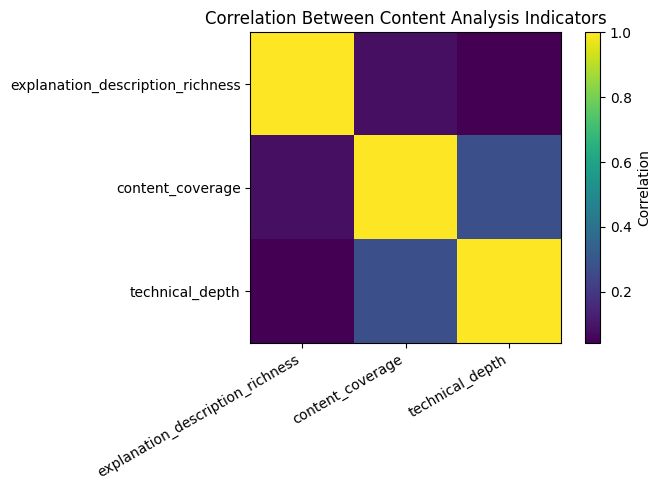

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.imshow(correlation, interpolation="nearest")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=30,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Between Content Analysis Indicators")

plt.tight_layout()
plt.show()

In [9]:
category_analysis = (
    analysis_df
    .groupby("Category")[
        [
            "explanation_description_richness",
            "content_coverage",
            "technical_depth"
        ]
    ]
    .mean()
    .sort_values(
        "explanation_description_richness",
        ascending=False
    )
)

category_analysis

,explanation_description_richness,content_coverage,technical_depth
Category,,,
Computer Vision & Multimodal AI,0.589075,0.797619,0.123810
Advanced Retrieval & Search,0.554144,0.863636,0.133333
LLM Systems & Inference Optimization,0.535471,0.833333,0.316667
Retrieval-Augmented Generation (RAG),0.506111,0.803571,0.123810
Large Language Models (LLM),0.505656,0.813333,0.104000
Agentic AI & Multi-Agent Systems,0.483817,0.807018,0.129825
Reinforcement Learning & Game Theory,0.460036,0.888889,0.207407
Generative AI & Diffusion Models,0.452859,0.858974,0.117949
Advanced Neural Architectures,0.452673,0.811111,0.315556


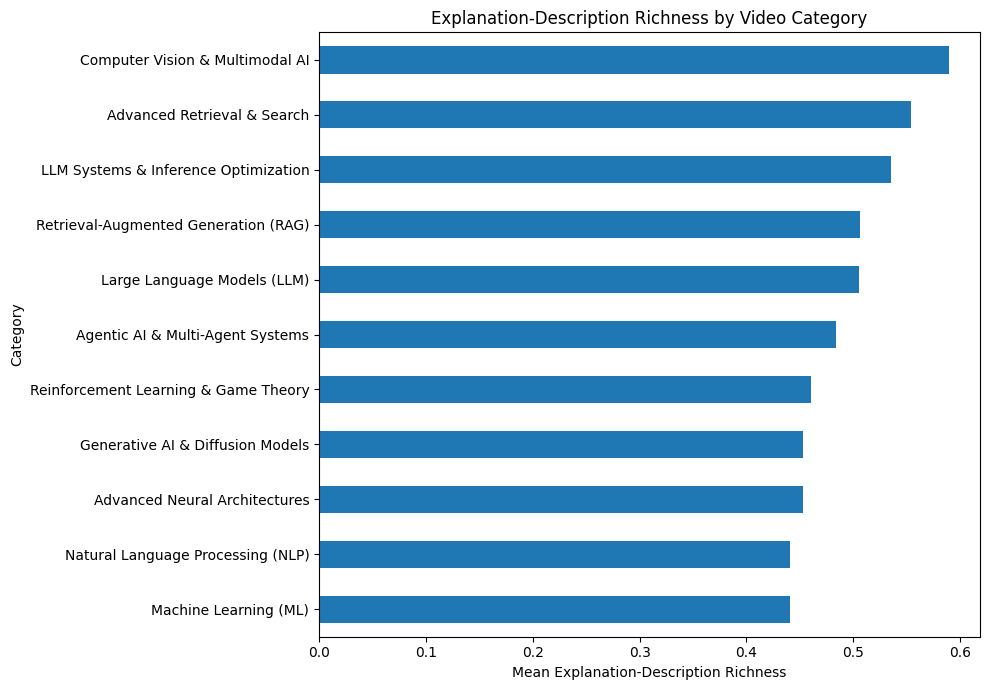

In [10]:
category_analysis["explanation_description_richness"].sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.xlabel("Mean Explanation-Description Richness")
plt.ylabel("Category")
plt.title("Explanation-Description Richness by Video Category")
plt.tight_layout()
plt.show()

In [11]:
cluster_analysis = (
    analysis_df
    .groupby("cluster")[
        [
            "explanation_description_richness",
            "content_coverage",
            "technical_depth"
        ]
    ]
    .mean()
    .sort_index()
)

cluster_analysis

,explanation_description_richness,content_coverage,technical_depth
cluster,,,
0,0.449547,0.829060,0.147009
1,0.518322,0.814103,0.179487
2,0.519130,0.824561,0.126316
3,0.443353,0.846154,0.189744
4,0.491049,0.801587,0.123810
5,0.444347,0.847222,0.122222
6,0.453791,0.883333,0.193333
7,0.519202,0.833333,0.231111
8,0.540721,0.796296,0.188889


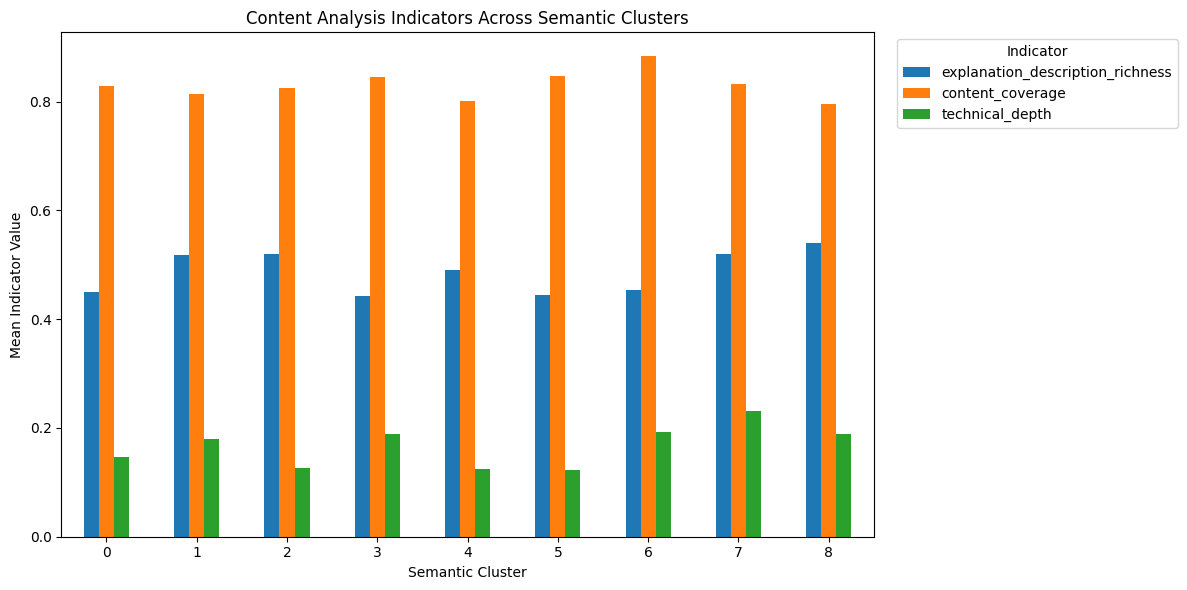

In [12]:
cluster_analysis.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Semantic Cluster")
plt.ylabel("Mean Indicator Value")
plt.title("Content Analysis Indicators Across Semantic Clusters")

plt.xticks(rotation=0)
plt.legend(
    title="Indicator",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [14]:
analysis_df["views_numeric"] = df["views_numeric"]

print(analysis_df["views_numeric"].dtype)
print(analysis_df["views_numeric"].head())

float64
0    24200000.0
1     9500000.0
2     1600000.0
3     1700000.0
4     1500000.0
Name: views_numeric, dtype: float64


In [15]:
views_correlation = analysis_df[
    [
        "views_numeric",
        "explanation_description_richness",
        "content_coverage",
        "technical_depth"
    ]
].corr()

views_correlation

,views_numeric,explanation_description_richness,content_coverage,technical_depth
views_numeric,1.000000,0.198291,-0.025351,0.017556
explanation_description_richness,0.198291,1.000000,0.082600,0.042796
content_coverage,-0.025351,0.082600,1.000000,0.277179
technical_depth,0.017556,0.042796,0.277179,1.000000


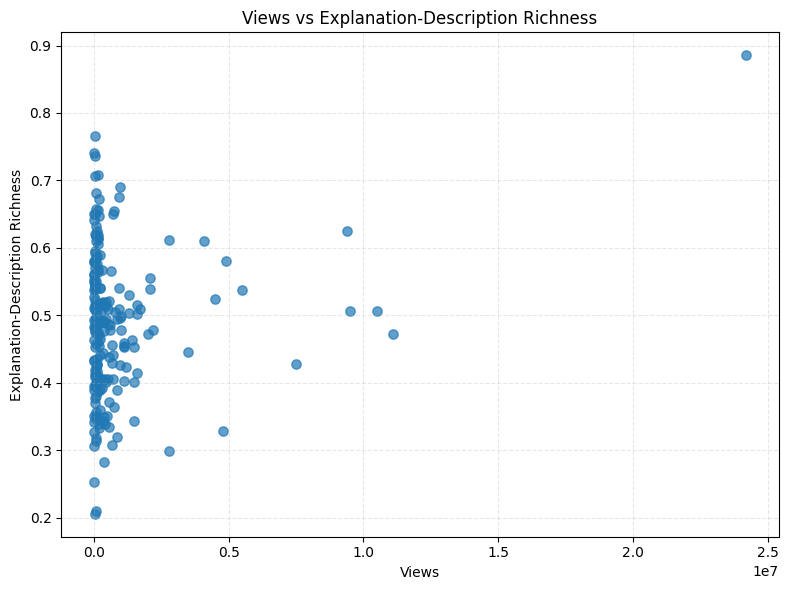

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["views_numeric"],
    analysis_df["explanation_description_richness"],
    alpha=0.7,
    s=45
)

plt.xlabel("Views")
plt.ylabel("Explanation-Description Richness")
plt.title("Views vs Explanation-Description Richness")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

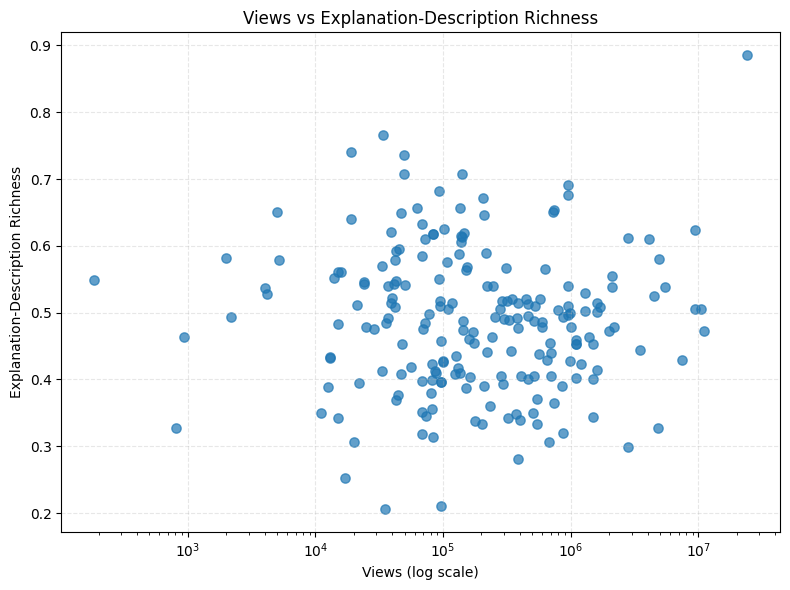

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["views_numeric"],
    analysis_df["explanation_description_richness"],
    alpha=0.7,
    s=45
)

plt.xscale("log")

plt.xlabel("Views (log scale)")
plt.ylabel("Explanation-Description Richness")
plt.title("Views vs Explanation-Description Richness")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [19]:
final_analysis = analysis_df[
    [
        "ID",
        "Title",
        "Category",
        "Channel",
        "Duration",
        "Views",
        "cluster",
        "explanation_description_richness",
        "content_coverage",
        "technical_depth"
    ]
].copy()

final_analysis.head()

,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,0,0.885600,0.833333,0.266667
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,0,0.505941,0.833333,0.466667
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,0,0.501331,0.833333,0.066667
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,06:36,1.7M+,0,0.509010,0.833333,0.000000
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,06:05,1.5M+,0,0.343270,0.833333,0.133333


In [24]:
output_path = "data/processed/video_content_analysis.csv"

final_analysis.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Shape:", final_analysis.shape)

Saved: data/processed/video_content_analysis.csv
Shape: (205, 10)


In [25]:
check_df = pd.read_csv(output_path)

print("Reloaded shape:", check_df.shape)
check_df.head()

Reloaded shape: (205, 10)


,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,0,0.885600,0.833333,0.266667
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,0,0.505941,0.833333,0.466667
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,0,0.501331,0.833333,0.066667
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,06:36,1.7M+,0,0.509010,0.833333,0.000000
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,06:05,1.5M+,0,0.343270,0.833333,0.133333


In [26]:
top_richness = final_analysis.sort_values(
    "explanation_description_richness",
    ascending=False
)[
    [
        "ID",
        "Title",
        "Category",
        "explanation_description_richness"
    ]
].head(10)

top_richness

,ID,Title,Category,explanation_description_richness
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),0.885600
143,VID-144,Faster LLMs: Accelerate Inference with Specula...,LLM Systems & Inference Optimization,0.765904
136,VID-137,Supercharge Your RAG with Contextualized Late ...,Advanced Retrieval & Search,0.741106
201,VID-202,"What is Multimodal AI? How LLMs Process Text, ...",Computer Vision & Multimodal AI,0.736712
145,VID-146,What is Low-Rank Adaptation (LoRA) | explained...,LLM Systems & Inference Optimization,0.707840
90,VID-091,Rerank for better RAG (Explained),Retrieval-Augmented Generation (RAG),0.706987
146,VID-147,What is YOLO algorithm? | Deep Learning Tutori...,Computer Vision & Multimodal AI,0.690825
86,VID-087,Advanced RAG techniques for developers,Retrieval-Augmented Generation (RAG),0.682028
83,VID-084,What is a Vector Database? Powering Semantic S...,Retrieval-Augmented Generation (RAG),0.675739
151,VID-152,NeRF: Representing Scenes as Neural Radiance F...,Computer Vision & Multimodal AI,0.672299


In [28]:
# Top 10 videos by explanation-description richness

top_richness = final_analysis.sort_values(
    "explanation_description_richness",
    ascending=False
)[
    [
        "ID",
        "Title",
        "Category",
        "explanation_description_richness"
    ]
].head(10)

top_richness

,ID,Title,Category,explanation_description_richness
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),0.885600
143,VID-144,Faster LLMs: Accelerate Inference with Specula...,LLM Systems & Inference Optimization,0.765904
136,VID-137,Supercharge Your RAG with Contextualized Late ...,Advanced Retrieval & Search,0.741106
201,VID-202,"What is Multimodal AI? How LLMs Process Text, ...",Computer Vision & Multimodal AI,0.736712
145,VID-146,What is Low-Rank Adaptation (LoRA) | explained...,LLM Systems & Inference Optimization,0.707840
90,VID-091,Rerank for better RAG (Explained),Retrieval-Augmented Generation (RAG),0.706987
146,VID-147,What is YOLO algorithm? | Deep Learning Tutori...,Computer Vision & Multimodal AI,0.690825
86,VID-087,Advanced RAG techniques for developers,Retrieval-Augmented Generation (RAG),0.682028
83,VID-084,What is a Vector Database? Powering Semantic S...,Retrieval-Augmented Generation (RAG),0.675739
151,VID-152,NeRF: Representing Scenes as Neural Radiance F...,Computer Vision & Multimodal AI,0.672299


In [29]:
# Top 10 videos by technical depth

top_technical = final_analysis.sort_values(
    "technical_depth",
    ascending=False
)[
    [
        "ID",
        "Title",
        "Category",
        "technical_depth"
    ]
].head(10)

top_technical

,ID,Title,Category,technical_depth
158,VID-159,Vision Transformer Quick Guide - Theory and Co...,Advanced Neural Architectures,1.000000
124,VID-125,Residual Networks and Skip Connections (DL 15),Advanced Neural Architectures,0.733333
188,VID-189,LoRA: Low-Rank Adaptation of Large Language Mo...,LLM Systems & Inference Optimization,0.733333
180,VID-181,Direct Preference Optimization (DPO) explained...,LLM Systems & Inference Optimization,0.533333
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),0.466667
197,VID-198,Simply Explaining Deep Q-Learning/Deep Q-Netwo...,Reinforcement Learning & Game Theory,0.466667
130,VID-131,AutoGen Tutorial 🚀 Create Custom AI Agents EAS...,Agentic AI & Multi-Agent Systems,0.400000
90,VID-091,Rerank for better RAG (Explained),Retrieval-Augmented Generation (RAG),0.400000
119,VID-120,Vision Transformers - Explained!,Advanced Neural Architectures,0.400000
40,VID-041,"Transformers, explained: Understand the model ...",Natural Language Processing (NLP),0.400000


In [30]:
# Top 10 videos by content coverage

top_coverage = final_analysis.sort_values(
    "content_coverage",
    ascending=False
)[
    [
        "ID",
        "Title",
        "Category",
        "content_coverage"
    ]
].head(10)

top_coverage

,ID,Title,Category,content_coverage
5,VID-006,Machine Learning Fundamentals: The Confusion M...,Machine Learning (ML),1.0
45,VID-046,NLP Basics Explained: Tokenization & Embeddings,Natural Language Processing (NLP),1.0
53,VID-054,Term Frequency Inverse Document Frequency (TF-...,Natural Language Processing (NLP),1.0
59,VID-060,Prompt Engineering Tutorial – Master ChatGPT a...,Large Language Models (LLM),1.0
43,VID-044,"Attention for Neural Networks, Clearly Explain...",Natural Language Processing (NLP),1.0
36,VID-037,What is Word2Vec? A Simple Explanation | Deep ...,Natural Language Processing (NLP),1.0
34,VID-035,"Word Embedding and Word2Vec, Clearly Explained!!!",Natural Language Processing (NLP),1.0
27,VID-028,Logistic Regression in 3 Minutes,Machine Learning (ML),1.0
28,VID-029,Machine Learning Crash Course: Gradient Descent,Machine Learning (ML),1.0
17,VID-018,Support Vector Machine (SVM) in 2 minutes,Machine Learning (ML),1.0


In [31]:
final_analysis["richness_percentile"] = (
    final_analysis["explanation_description_richness"]
    .rank(pct=True)
)

final_analysis["coverage_percentile"] = (
    final_analysis["content_coverage"]
    .rank(pct=True)
)

final_analysis["technical_percentile"] = (
    final_analysis["technical_depth"]
    .rank(pct=True)
)

final_analysis.head()

,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth,richness_percentile,coverage_percentile,technical_percentile
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,0,0.885600,0.833333,0.266667,1.000000,0.521951,0.800000
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,0,0.505941,0.833333,0.466667,0.575610,0.521951,0.978049
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,0,0.501331,0.833333,0.066667,0.556098,0.521951,0.282927
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,06:36,1.7M+,0,0.509010,0.833333,0.000000,0.595122,0.521951,0.080488
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,06:05,1.5M+,0,0.343270,0.833333,0.133333,0.092683,0.521951,0.502439


In [32]:
final_analysis["richness_percentile"] *= 100
final_analysis["coverage_percentile"] *= 100
final_analysis["technical_percentile"] *= 100

final_analysis.head()

,ID,Title,Category,Channel,Duration,Views,cluster,explanation_description_richness,content_coverage,technical_depth,richness_percentile,coverage_percentile,technical_percentile
0,VID-001,But what is a neural network? | Deep learning ...,Machine Learning (ML),3Blue1Brown,18:40,24.2M+,0,0.885600,0.833333,0.266667,100.000000,52.195122,80.000000
1,VID-002,"Gradient descent, how neural networks learn | ...",Machine Learning (ML),3Blue1Brown,20:33,9.5M+,0,0.505941,0.833333,0.466667,57.560976,52.195122,97.804878
2,VID-003,A Gentle Introduction to Machine Learning,Machine Learning (ML),StatQuest with Josh Starmer,12:45,1.6M+,0,0.501331,0.833333,0.066667,55.609756,52.195122,28.292683
3,VID-004,Machine Learning Fundamentals: Bias and Variance,Machine Learning (ML),StatQuest with Josh Starmer,06:36,1.7M+,0,0.509010,0.833333,0.000000,59.512195,52.195122,8.048780
4,VID-005,Machine Learning Fundamentals: Cross Validation,Machine Learning (ML),StatQuest with Josh Starmer,06:05,1.5M+,0,0.343270,0.833333,0.133333,9.268293,52.195122,50.243902


In [34]:
output_path = "data/processed/video_content_analysis.csv"

final_analysis.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Shape:", final_analysis.shape)

Saved: data/processed/video_content_analysis.csv
Shape: (205, 13)


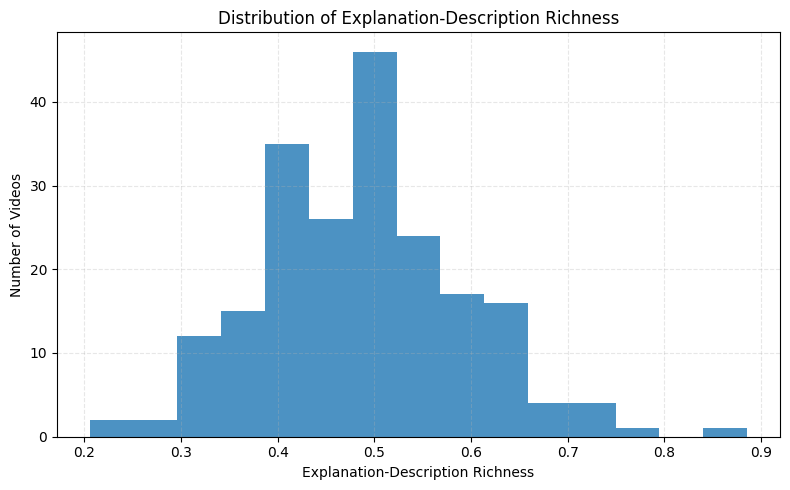

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    final_analysis["explanation_description_richness"],
    bins=15,
    alpha=0.8
)

plt.xlabel("Explanation-Description Richness")
plt.ylabel("Number of Videos")
plt.title("Distribution of Explanation-Description Richness")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

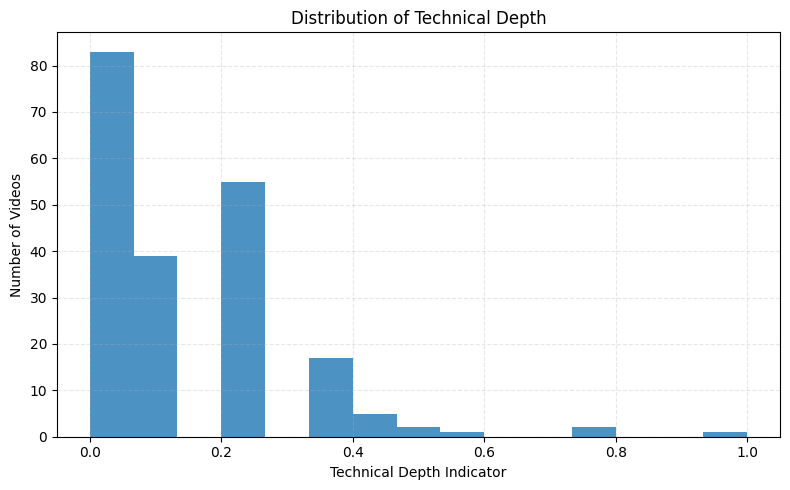

In [36]:
plt.figure(figsize=(8, 5))

plt.hist(
    final_analysis["technical_depth"],
    bins=15,
    alpha=0.8
)

plt.xlabel("Technical Depth Indicator")
plt.ylabel("Number of Videos")
plt.title("Distribution of Technical Depth")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

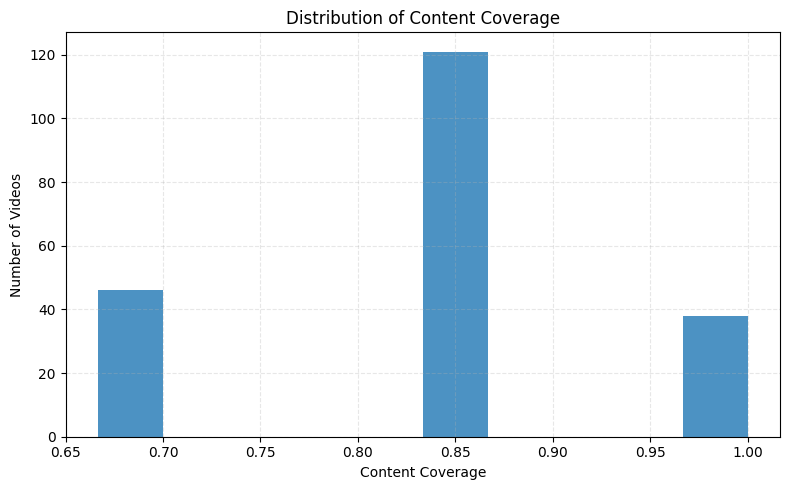

In [37]:
plt.figure(figsize=(8, 5))

plt.hist(
    final_analysis["content_coverage"],
    bins=10,
    alpha=0.8
)

plt.xlabel("Content Coverage")
plt.ylabel("Number of Videos")
plt.title("Distribution of Content Coverage")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

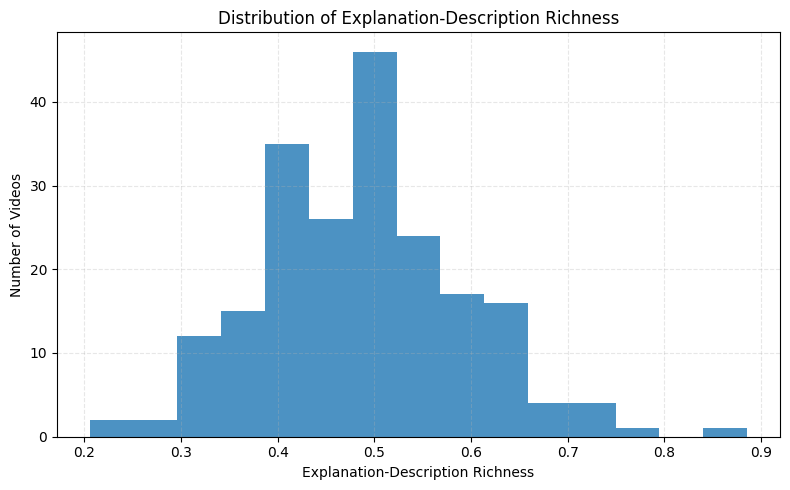

In [40]:
# Explanation richness
plt.figure(figsize=(8, 5))
plt.hist(final_analysis["explanation_description_richness"], bins=15, alpha=0.8)
plt.xlabel("Explanation-Description Richness")
plt.ylabel("Number of Videos")
plt.title("Distribution of Explanation-Description Richness")
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/explanation_richness_distribution.png", dpi=300)
plt.show()

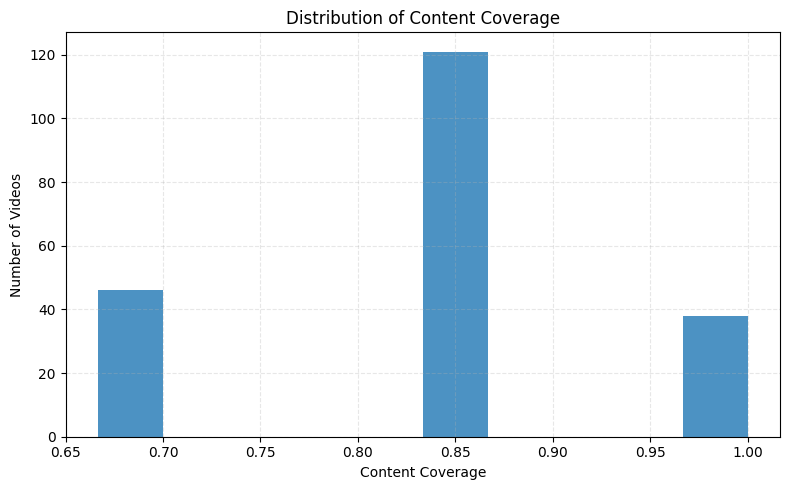

In [41]:
# Content coverage
plt.figure(figsize=(8, 5))
plt.hist(final_analysis["content_coverage"], bins=10, alpha=0.8)
plt.xlabel("Content Coverage")
plt.ylabel("Number of Videos")
plt.title("Distribution of Content Coverage")
plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("results/figures/content_coverage_distribution.png", dpi=300)
plt.show()